# 01 — Noise and inner-window sensitivity

**Question:** How accurately do SOLO, DOPPIO and LATTE recover known Gaussian-eddy parameters as observation noise increases, and how sensitive are they to the inner-core window?

Two targeted experiments compare the original inner estimators with a clearly labelled **local SOLO variant**. All use a local explicit-status outer fit, checked against the original on successful controls. Background flow, model misspecification, platform fusion, temporal evolution and tilt are outside this notebook. These representative configurations extend the paper's synthetic approach; they do not reproduce its tables exactly or provide a matched-data ranking of methods.

Set **SAVE_OUTPUTS** in the controls cell: `False` displays results only; `True` also writes CSVs, figures and provenance. Run top to bottom on Katana. Inspect the noise-free baseline and failure counts before interpreting the plots. No production data are required, and nothing is written to `ESP_zonodo`.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Supports launching from UNSW-PhD or from its esp directory.
HERE = Path.cwd().resolve()
if not (HERE / "validation_helpers.py").is_file():
    HERE = HERE / "esp"
if not (HERE / "validation_helpers.py").is_file():
    raise FileNotFoundError("Open this notebook from UNSW-PhD/esp or UNSW-PhD.")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
import validation_helpers as vh

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220})

## Controls

All fitting coordinates/radii are **metres**, unlike the kilometre convention in parts of the SEACOFS workflow. Angles are major-axis directions anticlockwise from east, modulo 180°. The negative rotation parameter represents a Southern Hemisphere cyclone.

Noise SD is specified **per velocity component**, relative to the peak absolute *normalised tangential speed* `|Omega| Rc / sqrt(2e)`. Correlated errors have covariance `sigma² exp(-distance² / (2 L²))`, with independent u/v error fields. These are controlled stress tests, not calibrated instrument uncertainties. Geometry and observation locations are fixed across repetitions.

In [2]:
SAVE_OUTPUTS = False              # True writes CSV/figures/provenance; False displays only
SOLO_CENTRE_GUESS_M = 10_000.0     # deliberately offset from synthetic centre; not read from truth
SOLO_SEARCH_HALF_WIDTH_M = 60_000.0  # fixed across all inner-window settings

ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
QUICK_RUN = False                  # True: 20 repeats; False: 100 repeats
N_REPEATS = 20 if QUICK_RUN else 100
SEED = 20261008
GEOMETRY_SEED = 1729

RC_M = 85_000.0
OMEGA = -6.9e-5
ELLIPSE_ALPHA = 1.527525
ELLIPSE_ANGLE_DEG = 35.0
TRANSECT_SPACING_M = 2_500.0
OUTER_EXTENT_RC = 2.0              # fixed sampled domain, not an adaptive fitted mask
BASELINE_CORE_M = 30_000.0
RC_LIMIT_M = 100_000.0             # retain original outer-fit default; diagnose fallback

NOISE_FRACTIONS = [0.0, 0.02, 0.05, 0.10, 0.20]
CORRELATION_LENGTH_RC = 0.15
WINDOW_RATIOS = [0.20, 0.30, BASELINE_CORE_M / RC_M, 0.45, 0.60]
WINDOW_NOISE_FRACTION = 0.05

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR = HERE / "results" / "01_noise_and_sampling" / RUN_ID

## Load the backend and record provenance

The exact requested `functions.py` is imported under a unique module name, avoiding accidental use of another file named `functions`. The imported backend is not modified. `local_estimators.py` contains the explicitly selected local variants. The SHA-256 fingerprint, available Git information, package versions, controls and local helper fingerprint are saved with every run.

**Local SOLO:** the approximate crossing is supplied as 10 km, deliberately offset from the true 0 km. A fixed ±60 km search interval identifies the nearest observed sign change; initial fitting is local and bounded. The inner refit also bounds the crossing to observed/search support and scales coordinates for conditioning. The parameter equations are unchanged. Thus this is a change in initialisation, fitting domain, constraints and numerical scaling, not just a different starting number. It assumes approximate location information and does not establish robustness to arbitrary initial guesses.

**Outer diagnostics:** `outer_fit_diagnostic` preserves the Gaussian objective, sign filter, peak initial guess and original 100 km post-fit limit. It returns `outer_optimisation_failed`, `outer_radius_limit`, `insufficient_outer` or `nonfinite_outer` explicitly. Attempted radius/rotation estimates survive a radius-limit failure. It does not substitute seed values. The original inner optimiser APIs still do not expose every convergence flag. Numerical validity is not a guarantee of accuracy.

The original completed notebook is retained as `01_original_backend_results.ipynb`. Restart the kernel before running this updated notebook to avoid cached helper imports.

In [3]:
esp, backend_info = vh.load_backend(ESP_ROOT)
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

def save_table(table, filename):
    if SAVE_OUTPUTS:
        table.to_csv(OUTPUT_DIR / filename, index=False)

def save_figure(figure, filename):
    if SAVE_OUTPUTS:
        figure.savefig(OUTPUT_DIR / filename)
settings = dict(
    save_outputs=SAVE_OUTPUTS, solo_centre_guess_m=SOLO_CENTRE_GUESS_M,
    solo_search_half_width_m=SOLO_SEARCH_HALF_WIDTH_M, quick_run=QUICK_RUN, repeats=N_REPEATS, seed=SEED, geometry_seed=GEOMETRY_SEED,
    Rc_m=RC_M, Omega=OMEGA, ellipse_alpha=ELLIPSE_ALPHA, ellipse_angle_deg=ELLIPSE_ANGLE_DEG,
    transect_spacing_m=TRANSECT_SPACING_M, outer_extent_Rc=OUTER_EXTENT_RC,
    baseline_core_m=BASELINE_CORE_M, Rc_limit_m=RC_LIMIT_M,
    noise_fractions=NOISE_FRACTIONS, correlation_length_Rc=CORRELATION_LENGTH_RC,
    window_ratios=WINDOW_RATIOS, window_noise_fraction=WINDOW_NOISE_FRACTION,
)
provenance = dict(run_id=RUN_ID, backend=backend_info, settings=settings,
    helper_sha256=hashlib.sha256((HERE / "validation_helpers.py").read_bytes()).hexdigest(),
    notebook_sha256=hashlib.sha256((HERE / "01_noise_and_sampling.ipynb").read_bytes()).hexdigest(),
    local_estimators_sha256=hashlib.sha256((HERE / "local_estimators.py").read_bytes()).hexdigest(),
    estimator_policy="Original inner estimators plus labelled SOLO local comparison; local explicit-status outer fit for all")
if SAVE_OUTPUTS:
    (OUTPUT_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2))
display(pd.Series(backend_info, name="Backend / environment"))
print("Results:", OUTPUT_DIR if SAVE_OUTPUTS else "Display only; no result files will be written")

path                     /home/z5297792/ESP_zonodo/functions.py
sha256        8e4b06fe4c144f7a70671ee913b6d27784f9cdb587e9b0...
python                                                   3.10.8
numpy                                                     2.2.6
pandas                                                    2.3.3
scipy                                                    1.15.3
matplotlib                                               3.10.7
git_commit             a5ce3a7bb9fc21560c3963fc5024db81d6a24184
git_status    M .ipynb_checkpoints/functions-checkpoint.py\n...
Name: Backend / environment, dtype: object

Results: Display only; no result files will be written


## Fixed sampling and noise-free baseline

- **SOLO:** an eastward transect at y=20 km through a circular Gaussian vortex. The backend locates closest approach and selects its own local window.
- **DOPPIO:** orthogonal transects intersecting at (10,10) km through an elliptical vortex. The shared intersection has one noise observation reused by both transects. Inner half-lengths are measured from that fixed intersection.
- **LATTE:** 240 fixed scattered points within 0.65 Rc of (10,10) km, plus 160 in the surrounding annulus out to 2 Rc. The inner selection is a physical circular window about (10,10) km, with no recentering in this controlled experiment.

All observed locations remain available to the outer fit at every window size. The backend's existing rotation-sign filter still applies; retained counts are recorded. Inner geometry/sample counts differ across methods. The truth is used to generate data and score results, not passed as fitting parameters. Inner approximation errors may remain even without noise.

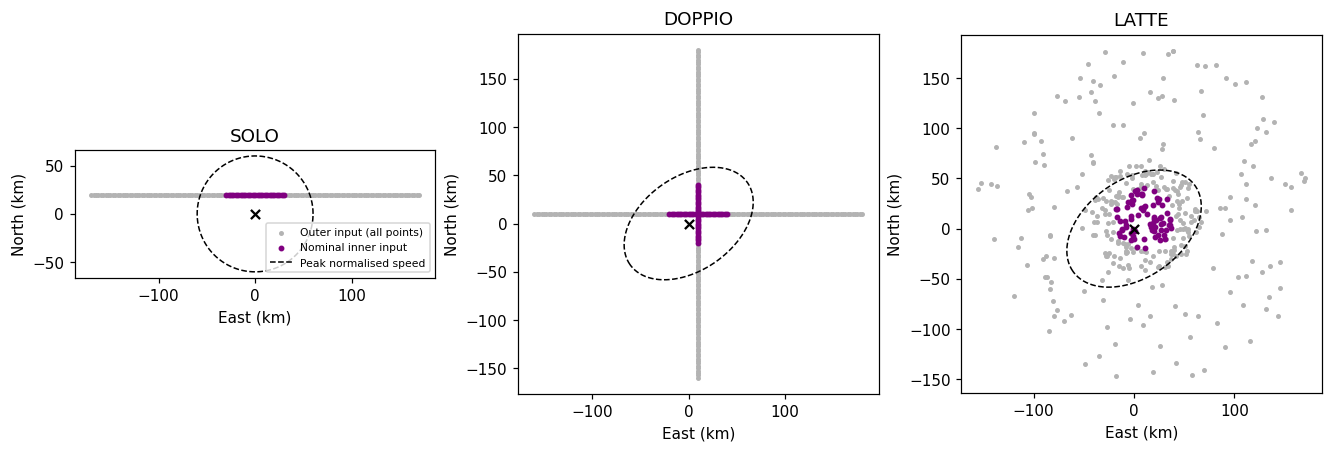

Diagnostic outer fit agrees with the original on noise-free controls.


,method,status,n_core,n_outer_retained,centre_error_km,Rc_error_pct,vorticity_error_pct,alpha_error_pct,angle_error_deg,warnings
0,SOLO,ok,25,137,0.025500,0.013287,-0.027926,NaN,NaN,
1,DOPPIO,ok,49,273,0.100469,0.037302,-0.057627,0.129161,0.016599,
2,LATTE,ok,76,400,0.103708,-0.097987,0.011605,-0.941688,1.331813,
3,SOLO local,ok,24,137,0.023545,0.012259,-0.025767,NaN,NaN,


,noise_fraction,component_noise_SD_m_s
0,0.00,0.000000
1,0.02,0.050308
2,0.05,0.125770
3,0.10,0.251539
4,0.20,0.503079


Reference speed = 2.515 m/s; correlation length = 12.75 km


In [4]:
cases = vh.make_cases(rc=RC_M, omega=OMEGA, alpha=ELLIPSE_ALPHA,
    angle_deg=ELLIPSE_ANGLE_DEG, spacing=TRANSECT_SPACING_M,
    outer_extent=OUTER_EXTENT_RC, seed=GEOMETRY_SEED)
fig = vh.plot_sampling(cases, BASELINE_CORE_M)
save_figure(fig, "sampling.png")
plt.show()

baseline = pd.DataFrame([
    dict(method=name, **vh.fit_case(esp, case, case["uv"], BASELINE_CORE_M, RC_LIMIT_M, diagnostic_outer=True))
    for name, case in cases.items()
])
# Confirm the diagnostic outer fit matches the original on these successful controls.
original_baseline = pd.DataFrame([
    dict(method=name, **vh.fit_case(esp, case, case["uv"], BASELINE_CORE_M, RC_LIMIT_M))
    for name, case in cases.items()
])
if not original_baseline.valid.all():
    raise RuntimeError("Original baseline failed; inspect backend compatibility.")
np.testing.assert_allclose(baseline[["Rc_m", "Omega", "psi0"]],
    original_baseline[["Rc_m", "Omega", "psi0"]], rtol=1e-5, atol=1e-10)
print("Diagnostic outer fit agrees with the original on noise-free controls.")
local_baseline = vh.fit_case(esp, cases["SOLO"], cases["SOLO"]["uv"], BASELINE_CORE_M,
    RC_LIMIT_M, diagnostic_outer=True, solo_local=True,
    centre_guess=SOLO_CENTRE_GUESS_M, search_half_width=SOLO_SEARCH_HALF_WIDTH_M)
baseline = pd.concat([baseline, pd.DataFrame([dict(method="SOLO local", **local_baseline)])], ignore_index=True)
save_table(baseline, "noise_free_baseline.csv")
display(baseline.reindex(columns=["method", "status", "n_core", "n_outer_retained",
    "centre_error_km", "Rc_error_pct", "vorticity_error_pct", "alpha_error_pct", "angle_error_deg", "warnings"]))
if not baseline.valid.all():
    raise RuntimeError("A noise-free baseline failed. Inspect diagnostics/backend before running ensembles.")

speed_ref = cases["SOLO"]["speed_ref"]
display(pd.DataFrame({"noise_fraction": NOISE_FRACTIONS,
    "component_noise_SD_m_s": np.asarray(NOISE_FRACTIONS) * speed_ref}))
print(f"Reference speed = {speed_ref:.3f} m/s; correlation length = {CORRELATION_LENGTH_RC * RC_M / 1000:.2f} km")

## A. Observation-noise sensitivity

Repeat both fitting stages for every noisy realisation. **SOLO** and **SOLO local** receive identical noisy observations, paired by experiment, error type, level and repeat. DOPPIO and LATTE retain their original inner estimators. Noise realisations are paired across amplitude levels within each method/error type. Independent and correlated errors use separate streams. Zero noise is evaluated once per method and is not an ensemble.

Plots show the median and 5th–95th percentiles **among valid fits**, alongside the valid-fit percentage over **all attempts**. Shading is simulation spread, not a confidence interval. Positive relative error means an overestimate of magnitude when the parameter retains its true sign. Centre error is unsigned. SOLO has no shape/orientation score because it imposes circularity.

noise: finished SOLO
noise: finished DOPPIO
noise: finished LATTE
noise: finished SOLO


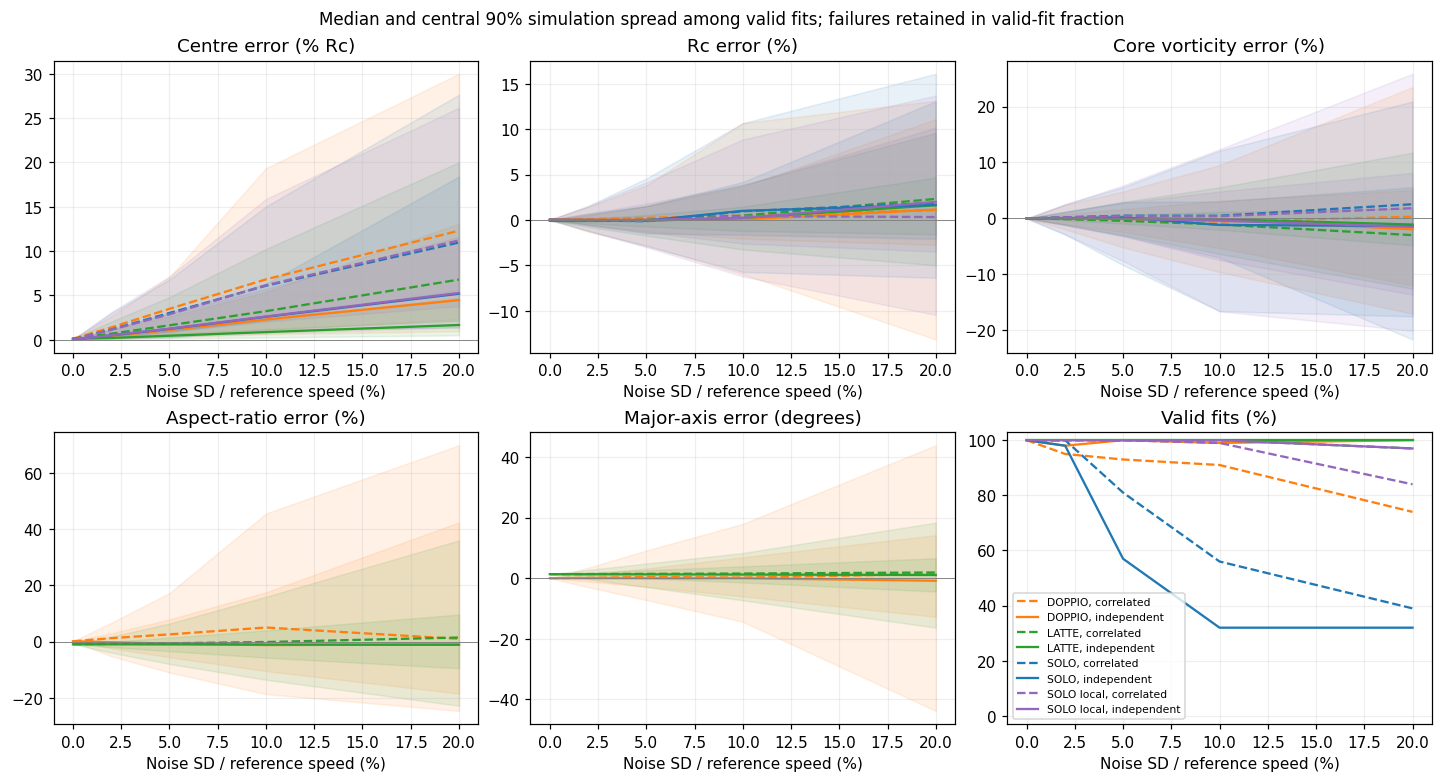

In [5]:
noise_results = vh.run_experiment(esp, cases, experiment="noise", levels=NOISE_FRACTIONS,
    repeats=N_REPEATS, seed=SEED, baseline_radius=BASELINE_CORE_M,
    correlation_fraction=CORRELATION_LENGTH_RC, rc_limit=RC_LIMIT_M, diagnostic_outer=True)
noise_local = vh.run_experiment(esp, {"SOLO": cases["SOLO"]}, experiment="noise",
    levels=NOISE_FRACTIONS, repeats=N_REPEATS, seed=SEED,
    baseline_radius=BASELINE_CORE_M, fixed_noise=WINDOW_NOISE_FRACTION,
    correlation_fraction=CORRELATION_LENGTH_RC, rc_limit=RC_LIMIT_M,
    diagnostic_outer=True, solo_local=True, centre_guess=SOLO_CENTRE_GUESS_M,
    search_half_width=SOLO_SEARCH_HALF_WIDTH_M)
noise_results = pd.concat([noise_results, noise_local], ignore_index=True)
noise_summary = vh.summarise(noise_results)
save_table(noise_results, "noise_attempts.csv")
save_table(noise_summary, "noise_summary.csv")
fig = vh.plot_results(noise_results)
for extension in ("png", "pdf"):
    save_figure(fig, f"noise_sensitivity.{extension}")
plt.show()

## B. Inner-window sensitivity

Hold noise amplitude, correlation length, outer observation locations and initial selection centres fixed. Change only the inner window, measured relative to the known synthetic Rc. Each realisation is shared across window sizes. This experiment uses a separate random stream from experiment A.

Smaller windows reduce sample size; larger windows depart further from the linear-core approximation. Sample counts therefore change with window size and are reported. These are sensitivity results, not independent validation of whichever window happens to look best.

window: finished SOLO
window: finished DOPPIO
window: finished LATTE
window: finished SOLO


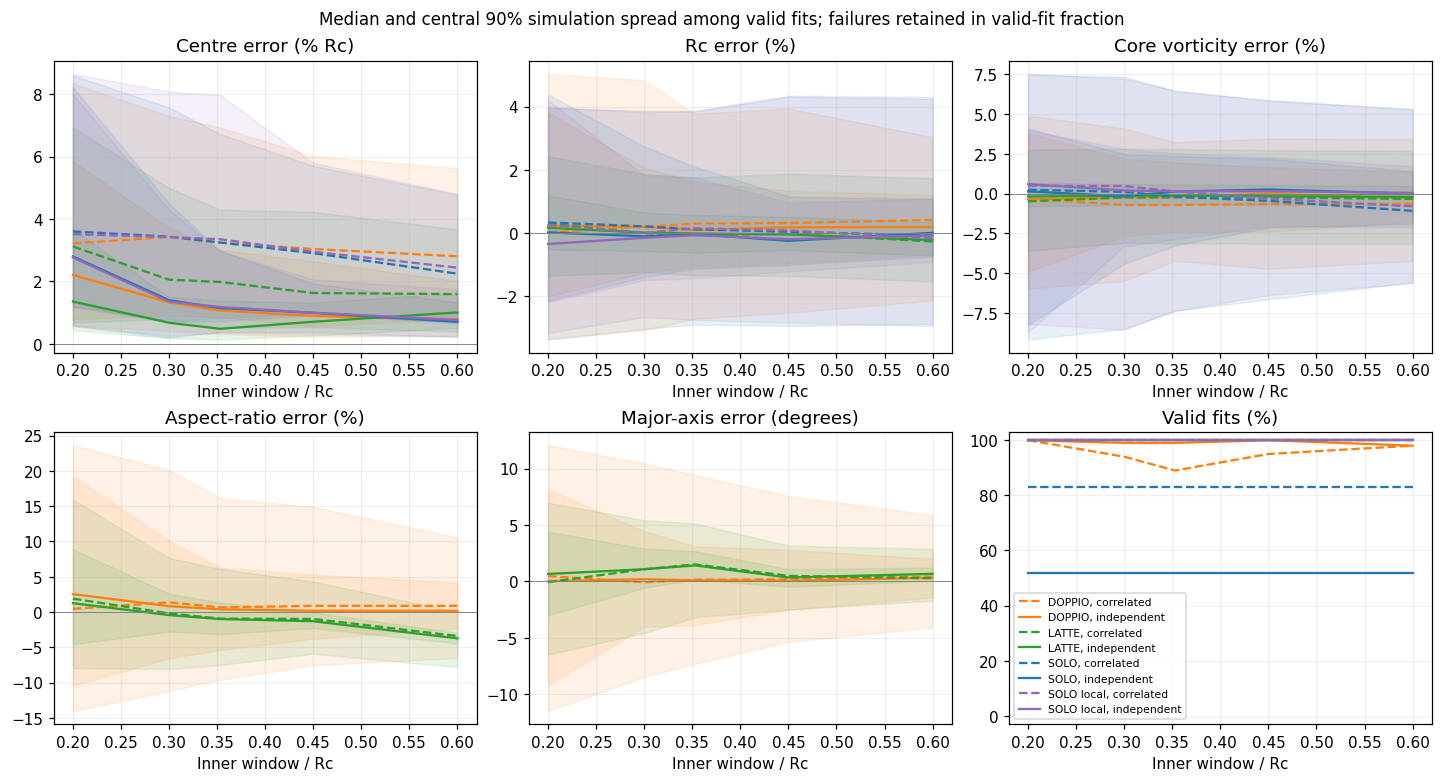

min  median  max
method     core_radius_ratio                  
DOPPIO     0.200000            25    25.0   25
           0.300000            41    41.0   41
           0.352941            49    49.0   49
           0.450000            61    61.0   61
           0.600000            81    81.0   81
LATTE      0.200000            23    23.0   23
           0.300000            54    54.0   54
           0.352941            76    76.0   76
           0.450000           129   129.0  129
           0.600000           204   204.0  204
SOLO       0.200000             0    13.0   14
           0.300000             0    20.0   21
           0.352941             0    24.0   24
           0.450000             0    31.0   31
           0.600000             0    41.0   41
SOLO local 0.200000            13    13.0   14
           0.300000            20    21.0   21
           0.352941            24    24.0   24
           0.450000            30    31.0   31
           0.600000            40    41.0   41

In [6]:
window_results = vh.run_experiment(esp, cases, experiment="window", levels=WINDOW_RATIOS,
    repeats=N_REPEATS, seed=SEED, fixed_noise=WINDOW_NOISE_FRACTION,
    correlation_fraction=CORRELATION_LENGTH_RC, rc_limit=RC_LIMIT_M, diagnostic_outer=True)
window_local = vh.run_experiment(esp, {"SOLO": cases["SOLO"]}, experiment="window",
    levels=WINDOW_RATIOS, repeats=N_REPEATS, seed=SEED,
    baseline_radius=BASELINE_CORE_M, fixed_noise=WINDOW_NOISE_FRACTION,
    correlation_fraction=CORRELATION_LENGTH_RC, rc_limit=RC_LIMIT_M,
    diagnostic_outer=True, solo_local=True, centre_guess=SOLO_CENTRE_GUESS_M,
    search_half_width=SOLO_SEARCH_HALF_WIDTH_M)
window_results = pd.concat([window_results, window_local], ignore_index=True)
window_summary = vh.summarise(window_results)
save_table(window_results, "window_attempts.csv")
save_table(window_summary, "window_summary.csv")
fig = vh.plot_results(window_results)
for extension in ("png", "pdf"):
    save_figure(fig, f"window_sensitivity.{extension}")
plt.show()

display(window_results.groupby(["method", "core_radius_ratio"])["n_core"].agg(["min", "median", "max"]))

## Summary and failure audit

Large errors are not removed using an accuracy cutoff. Failed fits remain in the denominator, with their reasons shown below. Outer failures now distinguish optimisation failures from radius-limit rejections; attempted fitted radii remain in the raw results. Exception messages and warnings are retained in the raw CSV files.

Orientation error is an axial difference in [-90°,90°). Its interpretation here concerns a moderately elliptical synthetic truth; near-circular real eddies require a separate orientation-identifiability assessment.

In [7]:
all_results = pd.concat([noise_results, window_results], ignore_index=True)
status_counts = (all_results.groupby(["experiment", "method", "noise_kind", "level", "status"])
    .size().rename("n").reset_index())
save_table(status_counts, "status_counts.csv")
summary = pd.concat([noise_summary, window_summary], ignore_index=True)
display(summary[["experiment", "method", "noise_kind", "level", "n_attempted", "n_valid",
    "valid_fraction", "centre_error_km_median", "Rc_error_pct_median", "vorticity_error_pct_median"]].round(3))
failures = status_counts[status_counts.status != "ok"]
display(failures if len(failures) else pd.DataFrame({"status": ["All attempts passed diagnostics"]}))
warned = all_results[all_results.warnings.fillna("").ne("")]
print(f"Attempts with recorded warnings: {len(warned)} / {len(all_results)}")
if len(warned):
    display(warned[["experiment", "method", "noise_kind", "level", "status", "warnings"]].head(10))
print("Saved run:" if SAVE_OUTPUTS else "Display-only run:", OUTPUT_DIR if SAVE_OUTPUTS else "nothing written")

,experiment,method,noise_kind,level,n_attempted,n_valid,valid_fraction,centre_error_km_median,Rc_error_pct_median,vorticity_error_pct_median
0,noise,SOLO,none,0.000,1,1,1.00,0.026,0.013,-0.028
1,noise,SOLO,independent,0.020,100,98,0.98,0.426,-0.003,0.005
2,noise,SOLO,independent,0.050,100,57,0.57,1.042,-0.075,0.159
3,noise,SOLO,independent,0.100,100,32,0.32,2.199,1.004,-1.199
4,noise,SOLO,independent,0.200,100,32,0.32,4.407,1.658,-1.400
...,...,...,...,...,...,...,...,...,...,...
71,window,SOLO local,correlated,0.200,100,100,1.00,2.989,0.250,0.493
72,window,SOLO local,correlated,0.300,100,100,1.00,2.905,-0.006,0.472
73,window,SOLO local,correlated,0.353,100,100,1.00,2.848,0.142,0.132
74,window,SOLO local,correlated,0.450,100,100,1.00,2.507,0.075,-0.316


,experiment,method,noise_kind,level,status,n
0,noise,DOPPIO,correlated,0.020000,nonfinite_inner,5
2,noise,DOPPIO,correlated,0.050000,nonfinite_inner,7
4,noise,DOPPIO,correlated,0.100000,nonfinite_inner,7
6,noise,DOPPIO,correlated,0.100000,outer_radius_limit,2
7,noise,DOPPIO,correlated,0.200000,nonfinite_inner,6
9,noise,DOPPIO,correlated,0.200000,outer_radius_limit,20
10,noise,DOPPIO,independent,0.020000,nonfinite_inner,2
13,noise,DOPPIO,independent,0.100000,nonfinite_inner,1
21,noise,LATTE,correlated,0.200000,outer_radius_limit,3
28,noise,SOLO,correlated,0.050000,exception,16


Attempts with recorded warnings: 0 / 7204
Display-only run: nothing written


## Interpretation to write after running

1. Is there appreciable noise-free bias, and does it differ by parameter?
2. How do correlated errors change recovery and failure frequency at the same component SD?
3. Which window ranges give stable estimates, and how many observations support them?
4. Do acceptable medians conceal broad spread or frequent failures?
5. Are errors driven by physical limitations, numerical failures or radius-limit fallbacks?

**For the revision:** select a compact noise figure and, if useful, place the window figure in the supplement. Report the exact tested geometries and noise scales. These results support conditional performance statements, not general robustness to arbitrary sampling or non-Gaussian flow. No scientific conclusions are prefilled in this notebook.